# Telco Customer Churn: Exploratory Data Analysis

The plan for this notebook is simple: figure out what state the data is in, how lopsided the
target is, and which features seem to have something to do with churn. Every
decision should come from something seen here
first, rather than being assumed.

## What is churn, and why bother predicting it?

Churn means a customer leaving. For a telecom that's someone cancelling
their service. So the thing I'm trying to predict is a simple yes or no for
each customer (did they leave or not), which makes this a classification
problem.

It's worth predicting because winning a new customer costs a lot more than
keeping one you already have. You can flag the people who are about to leave,
so a retention team can step in before they go to offer a deal. The two ways of being wrong don't
cost the same, though. Flagging someone who was going to stay anyway just wastes
a cheap retention offer, but missing someone who actually leaves loses their
whole future revenue. That imbalance in cost comes back later when picking the
metrics and the cutoff.

The data itself is IBM's Telco Customer Churn set, about 7,000 customers with
their contract, how long they've been around, what they pay, which services
they have, and whether they churned.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)

(7043, 21)


## First look

Let me just load it and see what a row looks like. Each row is one customer:
some demographics, their account setup (how long they've been here, their
contract, what they pay), which services they're subscribed to, and whether
they left.

The `info()` call below is really a dtype check. One thing to watch: the
non-null counts can't be fully trusted, because pandas doesn't treat a blank
string as missing, so a column can look complete while hiding empty values.

In [19]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [21]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


## Churn rate

So about 26.5% of customers churned (1,869 out of 7,043). That's roughly one
leaver for every three stayers. It's imbalanced enough that plain accuracy is
going to be misleading (a model that just says "nobody leaves" would score 73%
and be useless), so I'll need to think about how to handle that when it comes to
training.

## Why is TotalCharges a string?

Something odd stands out in the dtypes above. MonthlyCharges is a float, as
you'd expect for a money column, but TotalCharges came in as text. That
shouldn't happen for a column of numbers, so something non-numeric must be
hiding in there. Let me dig into it.

In [22]:
converted = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(converted.isna().sum())

11


In [23]:
bad = df[converted.isna()]
print(bad[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


## What those TotalCharges blanks actually are

Here's the answer. All 11 of the problem rows have a tenure of 0 and a Churn of
"No". These are brand-new customers who haven't been billed yet, so the blank in
TotalCharges isn't corruption, it just means "nothing billed so far". The right
thing to fill it with is 0, not some average. Filling in the median would be
inventing a thousand-odd pounds of charges for people who've paid nothing.

The fact that all of them have "No" for churn makes sense too. You can't have
already left in the same snapshot where you've only just signed up, so a
customer with zero months behind them hasn't had the chance to churn yet. That's
another reason to treat these as perfectly real customers rather than junk to
throw away.

I could just delete the 11 rows and nobody would notice, but keeping them is
more honest, brand-new customers are exactly the kind of person the model will
have to score in real life. So: convert TotalCharges to a number, fill the
blanks with 0, keep all 11 rows.

## Checking the category values

Next I want to look at every text column and list out the distinct values it
takes. That tells me two things at once: whether the categories are spelled
consistently, and what kind of encoding each column is going to need later.

Quick note on the code below: newer pandas stores text as an Arrow-backed string
type rather than the old "object" type, so the usual trick of filtering on
`dtype == "object"` finds nothing. Defining the categorical columns as
"everything that isn't numeric" sidesteps that and works either way.

In [24]:
numeric = df.select_dtypes(include="number").columns
categorical = [c for c in df.columns if c not in numeric and c != "customerID"]
for c in categorical:
    print(c, "->", df[c].unique())

gender -> <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner -> <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents -> <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService -> <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines -> <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService -> <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup -> <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV -> <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies -> <ArrowStringArray>
['No', 'Yes', 'No internet serv

## What that dump tells me

Good news first: the data is tidy. Every Yes/No column is spelled consistently,
no weird junk values, no stray spaces. Worth checking rather than assuming.

The interesting thing is "No internet service" showing up across six columns
(OnlineSecurity down to StreamingMovies), plus "No phone service" in
MultipleLines. These aren't really separate facts. If someone has no internet,
all six of their internet add-ons automatically say "No internet service", so
the same piece of information is sitting in seven places at once.

So I'll collapse "No internet service" and "No phone service" down to plain
"No". Nothing is actually lost, because whether someone has internet is already
recorded in the InternetService column itself, I'm just not storing it seven
extra times.

While I'm here I can also see what encoding each column wants. Contract is
ordered (month-to-month, then one year, then two year is a real ladder).
PaymentMethod has four values with no natural order, so that'll be one-hot. The
Yes/No columns become 0/1. TotalCharges only shows up in this list because of
those 11 blanks I already dealt with.

## How churn relates to the features

Now the fun part: does anything actually predict churn? I'll look at three
things, each with a chart, churn rate by contract type, how tenure differs
between leavers and stayers, and how monthly charges differ. I'm using grey for
stayers and red for churners throughout (and I'll keep the same colours in the
pipeline charts later). I'm comparing rates within each group rather than raw
counts, since raw counts mostly just tell you how big each group is.

## Finding 1: contract type is the biggest signal

This is the standout. Contract here means the deal someone signed up to, not how
long they've been around. Month-to-month customers churn at 42.7%, which makes
sense: they can walk away at the end of any month for free, so the choice to
stay is live every single month. Two-year customers churn at just 2.8%, partly
because for most of that contract they literally can't leave without paying to
break it. One year sits in the middle at 11.3%. It's the commitment level of the
deal driving this, which is a separate thing from how loyal the customer is.

Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028


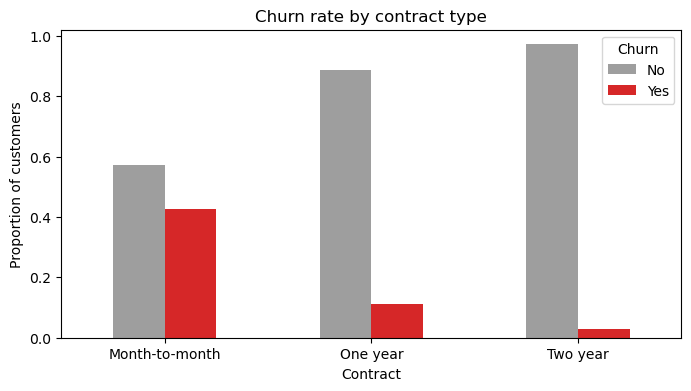

In [25]:
colors = {"No": "#9e9e9e", "Yes": "#d62728"}

contract_churn = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    .loc[["Month-to-month", "One year", "Two year"]]
)
print(contract_churn.round(3))

ax = contract_churn.plot(kind="bar", color=[colors["No"], colors["Yes"]], figsize=(8, 4))
ax.set_ylabel("Proportion of customers")
ax.set_title("Churn rate by contract type")
plt.xticks(rotation=0)
plt.show()

## Finding 2: churn happens early

Look at where the churners pile up, hard against the left of the tenure axis.
The riskiest time by far is the first few months, and the risk keeps dropping
the longer someone stays. The stayers are the opposite shape, with a big bump
out past 60 months where the long-term loyal customers live. So new customers
are really where retention effort should go. Worth noting tenure (how long
they've been here) and Contract (the type of deal) are related but genuinely
different things, and the model gets to see both.

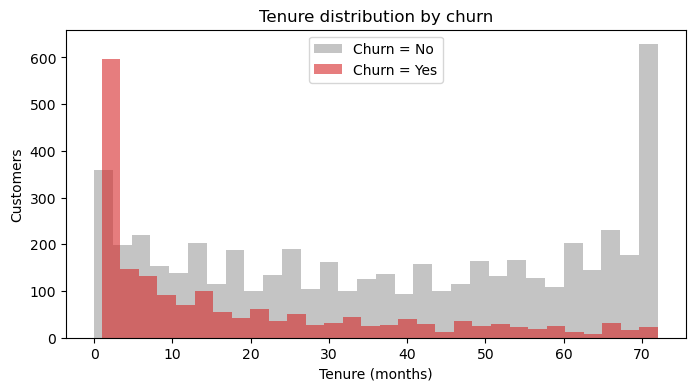

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
for label in ["No", "Yes"]:
    subset = df.loc[df["Churn"] == label, "tenure"]
    ax.hist(subset, bins=30, alpha=0.6, label=f"Churn = {label}", color=colors[label])
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Customers")
ax.set_title("Tenure distribution by churn")
ax.legend()
plt.show()

## Finding 3: pricier customers churn more

Churners clearly sit higher on monthly charges than stayers. I'd be careful
reading this as "price causes churn", though. High charges tend to come with
fibre internet, lots of services, and month-to-month contracts, so a chunk of
what this chart shows is really Finding 1 in disguise. Whether it's the price
itself pushing people out, or the things that happen to come with a high price,
is something I can't tell from here. SHAP should help pull those apart at the
end.

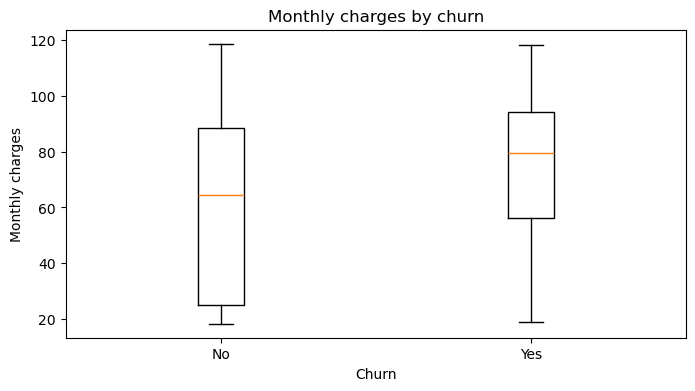

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
data = [df.loc[df["Churn"] == label, "MonthlyCharges"] for label in ["No", "Yes"]]
ax.boxplot(data, tick_labels=["No", "Yes"])
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly charges")
ax.set_title("Monthly charges by churn")
plt.show()

## Testing an engineered feature: billing drift

I'm planning to drop TotalCharges since it's basically tenure times
MonthlyCharges. But before I do, it's worth checking whether the leftover bit
(the actual total minus that simple product) holds any signal. If a customer's
bill drifted up or down over time, that gap would capture it, and it might be
worth keeping as its own feature. Let me see.

In [28]:
# Drift: how far actual billing sits from tenure x current monthly charge
tc = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
drift = tc - (df["tenure"] * df["MonthlyCharges"])
churn = (df["Churn"] == "Yes").astype(int)

print("corr(drift, churn):     ", round(drift.corr(churn), 3))
print("corr(MonthlyCharges, churn):", round(df["MonthlyCharges"].corr(churn), 3))
print("corr(tenure, churn):    ", round(df["tenure"].corr(churn), 3))
print()
print(drift.groupby(churn).describe().round(1)[["mean", "50%", "std"]])

corr(drift, churn):      0.0
corr(MonthlyCharges, churn): 0.193
corr(tenure, churn):     -0.352

       mean  50%   std
Churn                 
0       0.1  0.0  70.9
1       0.2  0.0  55.8


So the drift correlates 0.00 with churn, basically nothing. And its spread is
symmetric around zero for both groups, which is what you'd expect from rounding
and part-months rather than any real effect. That's actually a stronger reason
to drop TotalCharges than just "it's correlated with tenure", the leftover part
is genuinely noise, so nothing is lost by removing it. The scatter below shows
the same thing: the drift fans out evenly with tenure and the churners and
stayers sit right on top of each other.

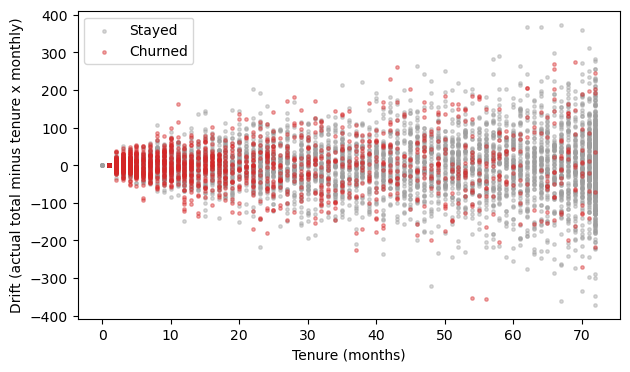

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, name in [(0, "Stayed"), (1, "Churned")]:
    ax.scatter(df.loc[churn == label, "tenure"], drift[churn == label],
               s=6, alpha=0.4, label=name,
               color="#9e9e9e" if label == 0 else "#d62728")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Drift (actual total minus tenure x monthly)")
ax.legend()
plt.show()

## Testing another engineered feature: number of services

Here's another idea. What if I count how many services each customer has, from 0
to 8? The thinking is that someone with lots of services is more tangled up with
the company and less likely to leave, and it would fold eight columns into one
tidy number. Let me check whether it actually holds up.

In [30]:
service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# raw df still has 'No phone service' / 'No internet service', so count Yes only
num_services = (df[service_cols] == "Yes").sum(axis=1)
churn = (df["Churn"] == "Yes").astype(int)

print("corr(num_services, churn):", round(num_services.corr(churn), 3))
print()
print(pd.crosstab(num_services, df["Churn"], normalize="index").round(3))
print()
print(num_services.value_counts().sort_index())

corr(num_services, churn): -0.067

Churn     No    Yes
row_0              
0      0.562  0.438
1      0.789  0.211
2      0.672  0.328
3      0.635  0.365
4      0.687  0.313
5      0.744  0.256
6      0.775  0.225
7      0.876  0.124
8      0.947  0.053

0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


In [31]:
# Who are the one-service customers?
print("InternetService by num_services (row %):")
print(pd.crosstab(num_services, df["InternetService"], normalize="index").round(3))
print()
print("Contract by num_services (row %):")
print(pd.crosstab(num_services, df["Contract"], normalize="index").round(3))
print()
print("Mean MonthlyCharges by num_services:")
print(df.groupby(num_services)["MonthlyCharges"].mean().round(2))

InternetService by num_services (row %):
InternetService    DSL  Fiber optic     No
row_0                                     
0                1.000        0.000  0.000
1                0.167        0.137  0.696
2                0.349        0.363  0.288
3                0.463        0.537  0.000
4                0.397        0.603  0.000
5                0.378        0.622  0.000
6                0.364        0.636  0.000
7                0.387        0.613  0.000
8                0.418        0.582  0.000

Contract by num_services (row %):
Contract  Month-to-month  One year  Two year
row_0                                       
0                  0.938     0.062     0.000
1                  0.571     0.188     0.242
2                  0.677     0.113     0.210
3                  0.753     0.174     0.073
4                  0.651     0.228     0.121
5                  0.471     0.308     0.220
6                  0.299     0.334     0.367
7                  0.157     0.266     0.577
8

The correlation is -0.07, close to zero, but that number is
hiding something. Churn actually starts at 43.8% for zero services, drops to
21.1% at one, climbs back up to 36.5% at three, then falls away to 5.3% at
eight. It's a U-ish shape, and a straight-line correlation just cancels it out
to nothing.

The crosstabs below explain what's really going on: the shape is Contract and
MonthlyCharges wearing a disguise. The month-to-month share follows the churn
curve almost exactly, and the average bill climbs steadily from about £25 to
£105 as the service count goes up. So this feature isn't telling me anything new,
it's just re-describing things I already have, and worse, it would pull SHAP
credit away from Contract, which is the feature actually doing the work. So I'm
leaving it out.

## Working out the cost ratio for the threshold

One more thing I can settle here. The model will output a probability, but at
some point I have to pick a cutoff for when to actually flag someone. Where that
cutoff goes depends on how the two mistakes compare: missing a churner (losing
their revenue) versus wasting a retention offer on someone who'd have stayed.
Instead of pulling a ratio out of thin air, I'd rather work it out from the
data.

In [32]:
avg_bill = df["MonthlyCharges"].mean()
avg_bill_churners = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].mean()

print(f"avg monthly bill (all):      £{avg_bill:.2f}")
print(f"avg monthly bill (churners): £{avg_bill_churners:.2f}")

avg monthly bill (all):      £64.76
avg monthly bill (churners): £74.44


In [33]:
horizon_months = 12       # how long a saved customer would have stayed
discount_depth = 10       # £/month the retention offer costs you

fn_cost = avg_bill_churners * horizon_months   # lost customer: their bill, gone
fp_cost = discount_depth * horizon_months      # wasted offer: discount, for nothing

print(f"false negative cost: £{fn_cost:.0f}  (lose a churner for {horizon_months} months)")
print(f"false positive cost: £{fp_cost:.0f}  (wasted discount for {horizon_months} months)")
print(f"ratio FN:FP = {fn_cost/fp_cost:.1f} : 1")

false negative cost: £893  (lose a churner for 12 months)
false positive cost: £120  (wasted discount for 12 months)
ratio FN:FP = 7.4 : 1


Churners pay about £74 a month on average, and say a retention discount costs
around £10 a month, that works out to roughly 7 to 1. The nice thing is the time
horizon drops out of the ratio entirely (it multiplies both sides equally), so
the whole thing really just hangs on the discount assumption. That 7:1 is what I
feed into the threshold search during training, where I also check a couple of
nearby ratios to see how sensitive the cutoff is to that assumption.

## Wrapping up: what carries forward

Pulling it all together, here's what came out of the EDA and what each thing
means for the pipeline:

1. Churn rate is 26.5% (1,869 of 7,043), imbalanced at roughly 2.8 to 1, so
   accuracy will mislead and training needs a real imbalance strategy.
2. TotalCharges came in as text because 11 rows are blank, all of them tenure-0
   customers who haven't been billed. Fill those with 0 and keep the rows. (The
   drift check confirmed the column is redundant anyway.)
3. "No internet service" and "No phone service" just duplicate what's already in
   InternetService and PhoneService, so collapse them to "No".
4. Contract is ordered, but its churn steps are wildly uneven (42.7%, 11.3%,
   2.8%), so I'll one-hot it rather than assume equal spacing with an ordinal
   encoding. PaymentMethod and InternetService are one-hot too, and the Yes/No
   columns become 0/1.
5. The big relationships are month-to-month contracts, low tenure, and high
   charges. These are the things I'll expect SHAP to confirm (or complicate)
   later.
6. Two engineered features (billing drift and a service count) got tested and
   thrown out, neither added anything on its own.
7. The cost ratio for the threshold works out to about 7 to 1 from the data.

In [35]:
import pandas as pd
preds = pd.read_csv("../data/test/predictions.csv")

print(preds.head(10))          # top of the worklist, highest risk first
print("...")
print(preds.tail(5))           # lowest risk
print()
print("flagged:", preds["churn_flag"].sum(), "of", len(preds))

# the three edge cases we seeded in
print(preds[preds["customerID"].str.startswith("EDGE")])

     customerID  churn_probability  churn_flag
0  EDGE-tenure0             0.8918           1
1     GEN-00176             0.7805           1
2     GEN-00037             0.6933           1
3     GEN-00081             0.6108           1
4     GEN-00024             0.5811           1
5     GEN-00001             0.5681           1
6     GEN-00185             0.5186           1
7     GEN-00182             0.4678           1
8     GEN-00062             0.4414           1
9     GEN-00064             0.4307           1
...
    customerID  churn_probability  churn_flag
198  GEN-00114             0.0147           0
199  GEN-00160             0.0147           0
200  GEN-00135             0.0139           0
201  GEN-00041             0.0126           0
202  GEN-00038             0.0114           0

flagged: 92 of 203
           customerID  churn_probability  churn_flag
0        EDGE-tenure0             0.8918           1
152   EDGE-noservices             0.0696           0
169  EDGE-allservices   